# Logistikk: forsyningskjeder

## Matrisa til en forsyningskjede

Sunn Snacks AS er et selskap som produserer og distribuerer sunne snacks som muslibarer, tørket frukt og nøtteblandinger.

Produksjonen foregår i 3 fabrikker, som produserer henholdsvis muslibarer, nøtteblandinger og tørket frukt. Råvarene er havre, nøtter, og rosiner.

Vi skal sette opp ei matrise A slik at raten lagerføring av varer endrer seg til enhver tid er $A\vec{u}$, hvor $\vec{u}$ er produksjonsraten av de forskjellige fabrikkene. 

For å være mer presis, $\vec{u}$ er en vektor med 5 komponenter: den første er mengde råvarer som produseres/høstes inn per tidsenhet, den siste er konsumentens forbruk per tidsenhet, og de midterste tre er hvor mange produkter hver fabrikk produserer. Resultatet $A\vec{u}$ er da en vektor med seks komponenter som er endring per tidsenhet i lagerføring av varene, henholdsvis havre, nøtter, rosiner, muslibarer, nøtteblandinger og tørket frukt.

Matrisa $A=D-C$ er forskjell av ei leveransematrise som inneholder all produksjon/innhøsting (som er positive), og ei forbruksmatrise som inneholder forbruk av konsumentene samt de forskjellige fabrikken. Den settes opp sånn:

## Matrisa

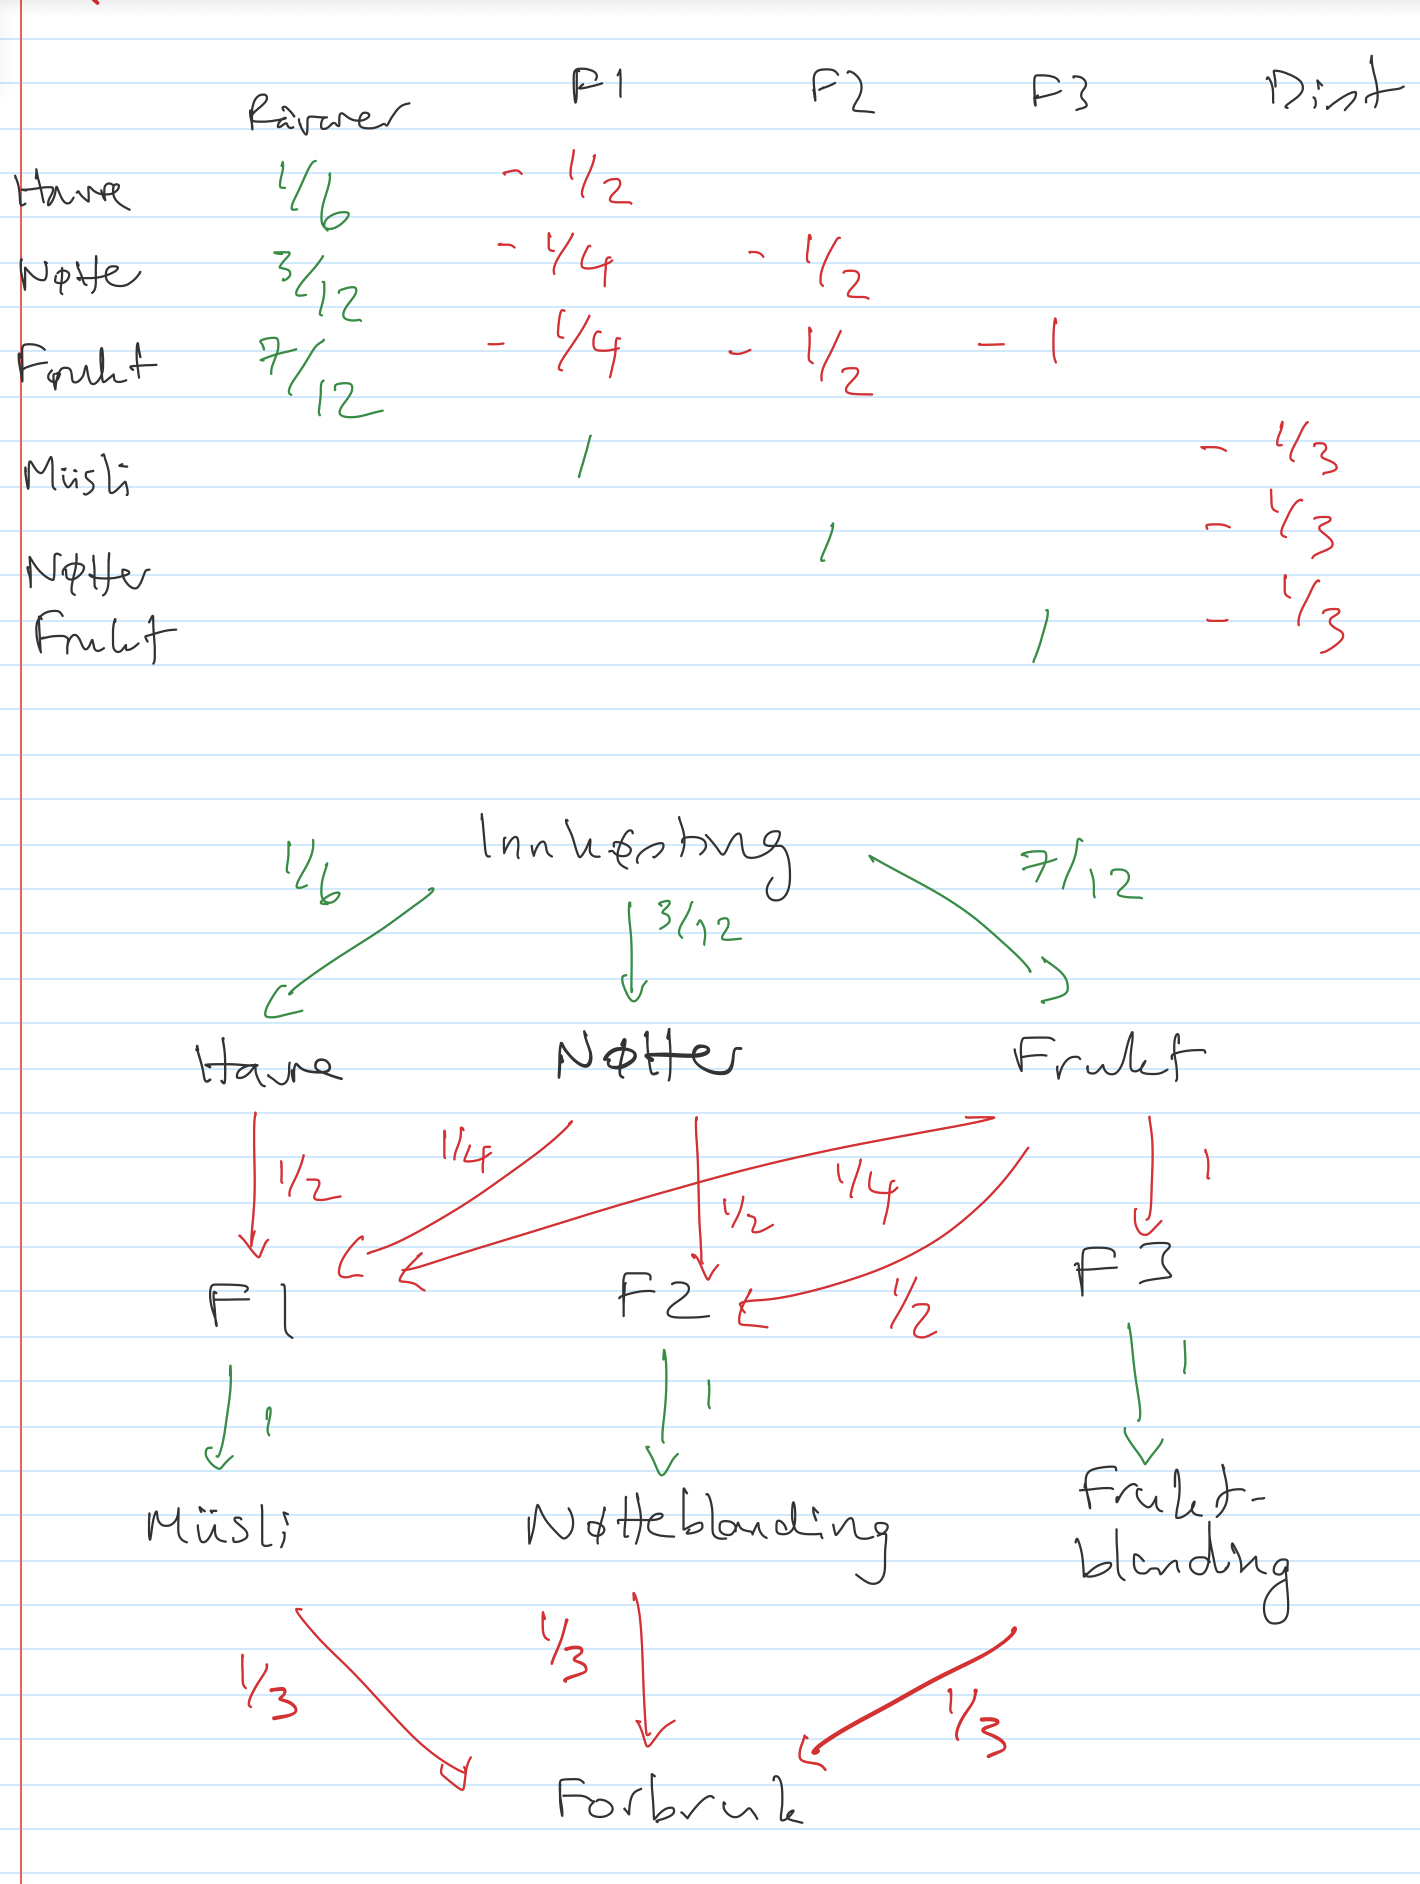

In [ ]:
import numpy as np

# Relativ innhøsting av havre, nøtter og rosiner
prod = np.array([1/6,3/12,7/12])

# Forbruk av fabrikk 1 i produksjon av muslibarer (altså en muslibar er 50% havre, 25% nøtter og 25% rosiner)
fab1 = np.array([1/2, 1/4, 1/4])

# Forbruk av fabrikk 2 ... nøtteblandinger (en nøtteblanding er 50% nøtter og 50% rosiner)
fab2 = np.array([0, 1/2, 1/2])

# Forbruk av fabrikk 3 - tørket frukt er 100% rosiner
fab3 = np.array([0, 0, 1])

# Etterspørsel av varer - det selges like mye av hvert produkt, altså 33% av salg er muslibarer osv
forbruk = np.array([1/3, 1/3, 1/3])

D = np.zeros([5,6])
C = np.zeros([5,6])

# Leveransematrisa
D[0,0:3]=prod
D[1,3]=1
D[2,4]=1
D[3,5]=1

# Forbruksmatrisa
C[1,0:3]=fab1
C[2,0:3]=fab2
C[3,0:3]=fab3
C[4,3:6]=forbruk

# Forsyningskjedematrise
A = np.transpose(D-C)
print(A)

## Nullrommet og likevekt

Senere i kurset skal vi se på utvikling over tid. Men for tiden fokuserer vi på likevekt. Er det altså mulig å justere produksjonsratene slik at lagerføring er konstant over tid? Svaret er at vi får likevekt når endringen $A\vec{u}=0$, dvs at vektor av ratene $\vec{u}$ er i nullrommet til matrisa $A$.

Å finne nullrommet med datamaskin er ikke en enkel sak. Den beste metoden er å bruke SVD (singular value decomposition), som ikke er pensum. Prat med din numerikklærer for å finne ut hvorfor vi liker det bedre enn redusert trappeform. Vi finner SVD under:

In [5]:
U, S, V = np.linalg.svd(A)
print(S)

[1.67222914e+00 1.15835762e+00 1.06830100e+00 5.99565816e-01
 4.57851608e-17]


Hvis et av tallene over er lik (eller nesten lik) null, er nullrommet ikke tomt. Her ser vi at den 5. tall i S er tilnærmet null. Da er den 5. raden i V i nullrommet. Siden python teller fra 0 finner vi det ved å sette i=5-1=4 under:

In [10]:
i = 4
print(V[i,1:4]/V[i,0])


[0.33333333 0.33333333 0.33333333]


Likevekten er altså at vi produserer like mye av hvert produkt.

# Oppgaver

## Sunn snacks AS

1. Hva om forbruket endrer seg? Kanskje er muslibarer dobbelt så populære som nøtteblandinger og tørket frukt! Endre koden og kjør på nytt.
2. Du burde finne at nullrommet blir trivielt, altså ingen produksjon blir den eneste likevekt. Din oppgave er å endre produksjon av råvarer (relativ innhøsting) slik at du får et ikke-trivielt nullrom. (Hint: du burde løse et lineært system! Men hva?)
3. Finn da en produksjonsvektor som gir likevekt nå.

## En ny kjede
4. Din tur! Finn på en forsyningskjede med minst 3 "fabrikker" (i tillegg til inn og ut), og modifiser koden over til å komme på en tilsvarende matrisa A for kjeden.
5. Finner du en likevekt? Hvis ikke, modifiser noen parametrer i kjeden (f. eks. produksjon av råvarer) slik at du får likevekt.